In [11]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as LA

In [4]:
ts = np.linspace(0, 1, 21)

In [36]:
ys = np.cos(2*np.pi*ts)

In [37]:
ys

array([ 1.00000000e+00,  9.51056516e-01,  8.09016994e-01,  5.87785252e-01,
        3.09016994e-01,  6.12323400e-17, -3.09016994e-01, -5.87785252e-01,
       -8.09016994e-01, -9.51056516e-01, -1.00000000e+00, -9.51056516e-01,
       -8.09016994e-01, -5.87785252e-01, -3.09016994e-01, -1.83697020e-16,
        3.09016994e-01,  5.87785252e-01,  8.09016994e-01,  9.51056516e-01,
        1.00000000e+00])

In [38]:
datapoints = np.column_stack((ts, ys))

In [39]:
def construct_poly(x, d):
    def poly(ts):
        return sum(x[k]*np.pow(ts, k) for k in range(d+1))
    return poly

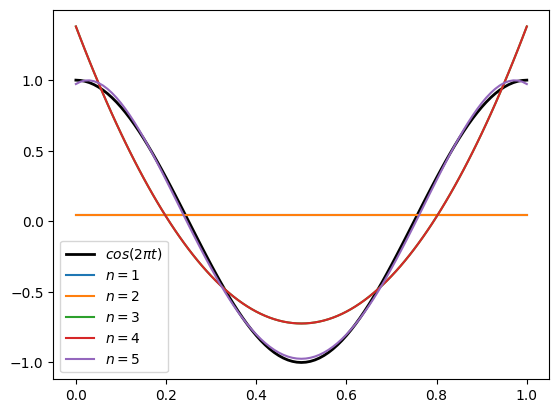

In [41]:
fig, ax = plt.subplots(1, 1)
ts_plot = np.linspace(0, 1, 101)
ax.plot(ts_plot, np.cos(2*np.pi*ts_plot), label=r"$cos(2\pi t)$", linewidth=2, color='black')
for n in range(1, 6):
    A = np.array([np.pow(ts, k) for k in range(n)]).T
    B = A.T @ A
    x = LA.solve(B, A.T @ ys)
    poly = construct_poly(x, n-1)
    ax.plot(ts_plot, poly(ts_plot), label=rf"$n={n}$")
ax.legend()